In [1]:
from astropy.table import Table
from astropy.io import fits
import numpy as np
import pylab as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as fitter
%matplotlib inline

## 1)

In [6]:
#1.1
pd.read_csv('global_air_quality.csv')

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AFR,Africa,Country,KEN,Kenya,Year,2019,...,NaN,NaN,6.29,NaN,13.74,10.01 [6.29-13.74],NaN,NaN,EN,2022-08-12 00:00:00
1,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,TTO,Trinidad and Tobago,Year,2019,...,NaN,NaN,7.44,NaN,12.55,10.02 [7.44-12.55],NaN,NaN,EN,2022-08-12 00:00:00
2,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,EUR,Europe,Country,GBR,United Kingdom of Great Britain and Northern I...,Year,2019,...,NaN,NaN,9.73,NaN,10.39,10.06 [9.73-10.39],NaN,NaN,EN,2022-08-12 00:00:00
3,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,GRD,Grenada,Year,2019,...,NaN,NaN,7.07,NaN,13.20,10.08 [7.07-13.20],NaN,NaN,EN,2022-08-12 00:00:00
4,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,BRA,Brazil,Year,2019,...,NaN,NaN,8.23,NaN,12.46,10.09 [8.23-12.46],NaN,NaN,EN,2022-08-12 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9445,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,BLZ,Belize,Year,2010,...,NaN,NaN,3.91,NaN,20.28,9.92 [3.91-20.28],NaN,NaN,EN,2022-08-12 00:00:00
9446,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,TTO,Trinidad and Tobago,Year,2010,...,NaN,NaN,7.80,NaN,12.89,9.92 [7.80-12.89],NaN,NaN,EN,2022-08-12 00:00:00
9447,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AFR,Africa,Country,KEN,Kenya,Year,2010,...,NaN,NaN,6.30,NaN,13.57,9.94 [6.30-13.57],NaN,NaN,EN,2022-08-12 00:00:00
9448,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,USA,United States of America,Year,2010,...,NaN,NaN,9.78,NaN,10.11,9.95 [9.78-10.11],NaN,NaN,EN,2022-08-12 00:00:00


In [34]:
#1.2
df = pd.read_csv('global_air_quality.csv')

df['PM25 Value'] = df['FactValueNumeric']

print(df[['FactValueNumeric', 'PM25 Value']])

      FactValueNumeric  PM25 Value
0                10.01       10.01
1                10.02       10.02
2                10.06       10.06
3                10.08       10.08
4                10.09       10.09
...                ...         ...
9445              9.92        9.92
9446              9.92        9.92
9447              9.94        9.94
9448              9.95        9.95
9449             92.79       92.79

[9450 rows x 2 columns]


In [42]:
#1.3
df.rename(columns={'FactValueNumeric': 'PM25 Value'}, inplace=True)

continent_avg = df.groupby('ParentLocation')['PM25 Value'].mean().reset_index()

continent_avg.rename(columns={'PM25 Value': 'Average PM25'}, inplace=True)

df = pd.merge(df, continent_avg, on='ParentLocation', how='left')

print(df[['Location', 'ParentLocation', 'PM25 Value']])

                                               Location  \
0                                                 Kenya   
1                                   Trinidad and Tobago   
2     United Kingdom of Great Britain and Northern I...   
3                                               Grenada   
4                                                Brazil   
...                                                 ...   
9445                                             Belize   
9446                                Trinidad and Tobago   
9447                                              Kenya   
9448                           United States of America   
9449                                        Afghanistan   

             ParentLocation  PM25 Value  
0                    Africa       10.01  
1                  Americas       10.02  
2                    Europe       10.06  
3                  Americas       10.08  
4                  Americas       10.09  
...                     ...         ...

In [44]:
#1.4
df.rename(columns={'FactValueNumeric': 'PM25 Value'}, inplace=True)

continent_avg = df.groupby('ParentLocation')['PM25 Value'].mean().reset_index()

continent_avg.rename(columns={'PM25 Value': 'Average PM25'}, inplace=True)

highest_avg_continent = continent_avg.loc[continent_avg['Average PM25'].idxmax()]

print(f"The continent with the highest average PM2.5 concentration is {highest_avg_continent['ParentLocation']} with an average concentration of {highest_avg_continent['Average PM25']}.")

The continent with the highest average PM2.5 concentration is Eastern Mediterranean with an average concentration of 38.40368181818182.


In [52]:
#1.5
df.rename(columns={'FactValueNumeric': 'PM25 Value'}, inplace=True)

continent_avg = df.groupby('ParentLocation')['PM25 Value'].mean().reset_index()

continent_avg.rename(columns={'PM25 Value : ParentLocation'}, inplace=True)

df = pd.merge(df, continent_avg, on='ParentLocation', how='left')

df_selected_columns = df[['Location', 'ParentLocation', 'PM25 Value']]

df_selected_columns.to_csv('updated_air_quality_data.csv', index=False)

print("The updated DataFrame has been saved to 'updated_air_quality_data.csv'.")

TypeError: 'set' object is not callable

## 2)

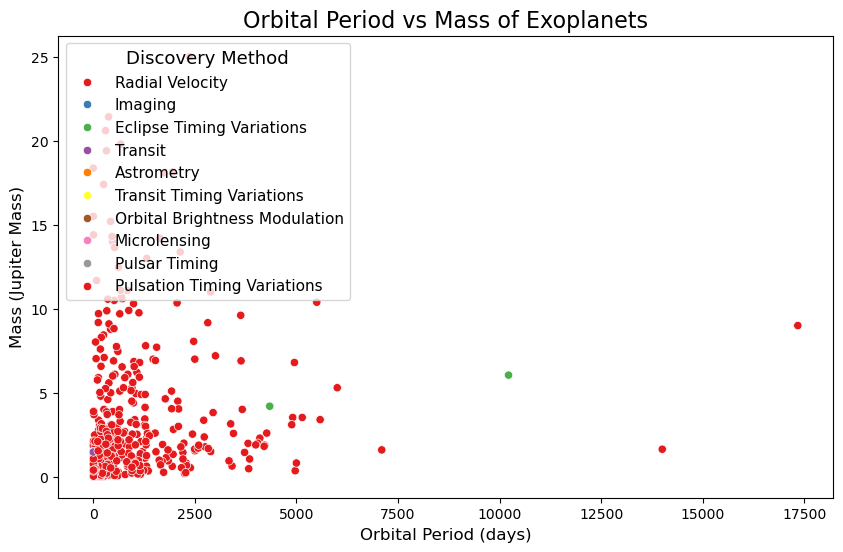

In [67]:
#2.1
df = sns.load_dataset('planets')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='orbital_period', y='mass', hue='method', palette='Set1')
plt.title('Orbital Period vs Mass of Exoplanets', fontsize=16)
plt.xlabel('Orbital Period (days)', fontsize=12)
plt.ylabel('Mass (Jupiter Mass)', fontsize=12)
plt.legend(title='Discovery Method', title_fontsize='13', fontsize='11', loc='upper left')
plt.show()

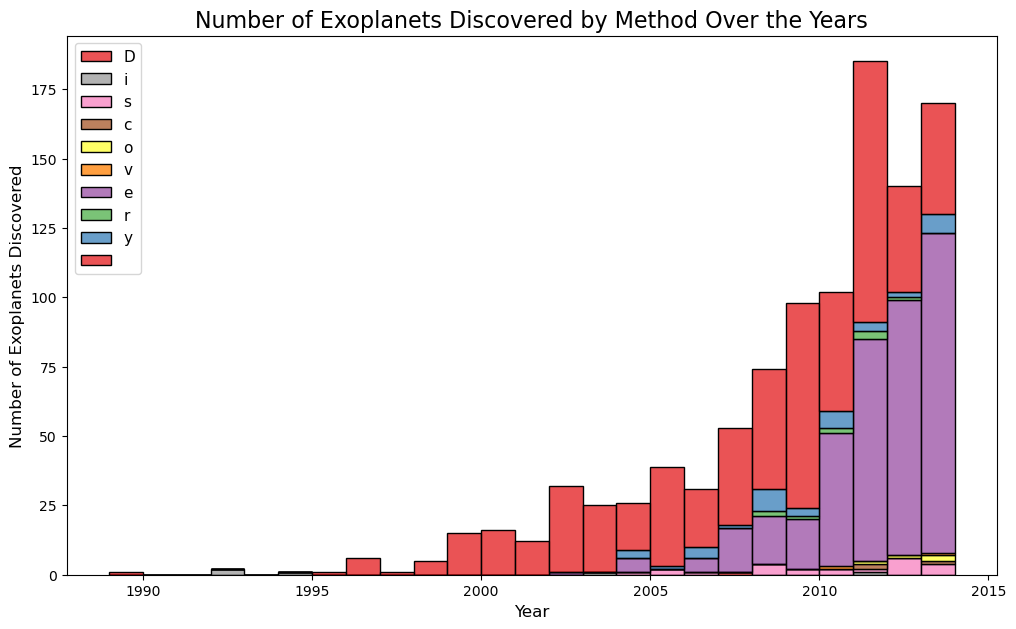

In [85]:
#2.2
df = sns.load_dataset('planets')
df_cleaned = df.dropna(subset=['year', 'method'])
plt.figure(figsize=(12, 7))
sns.histplot(data=df_cleaned, x='year', hue='method', multiple='stack', palette='Set1', bins=range(int(df_cleaned['year'].min()), int(df_cleaned['year'].max()) + 1))
plt.title('Number of Exoplanets Discovered by Method Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Exoplanets Discovered', fontsize=12)
plt.legend('Discovery Method', title_fontsize='13', fontsize='11', loc='upper left')
plt.show()